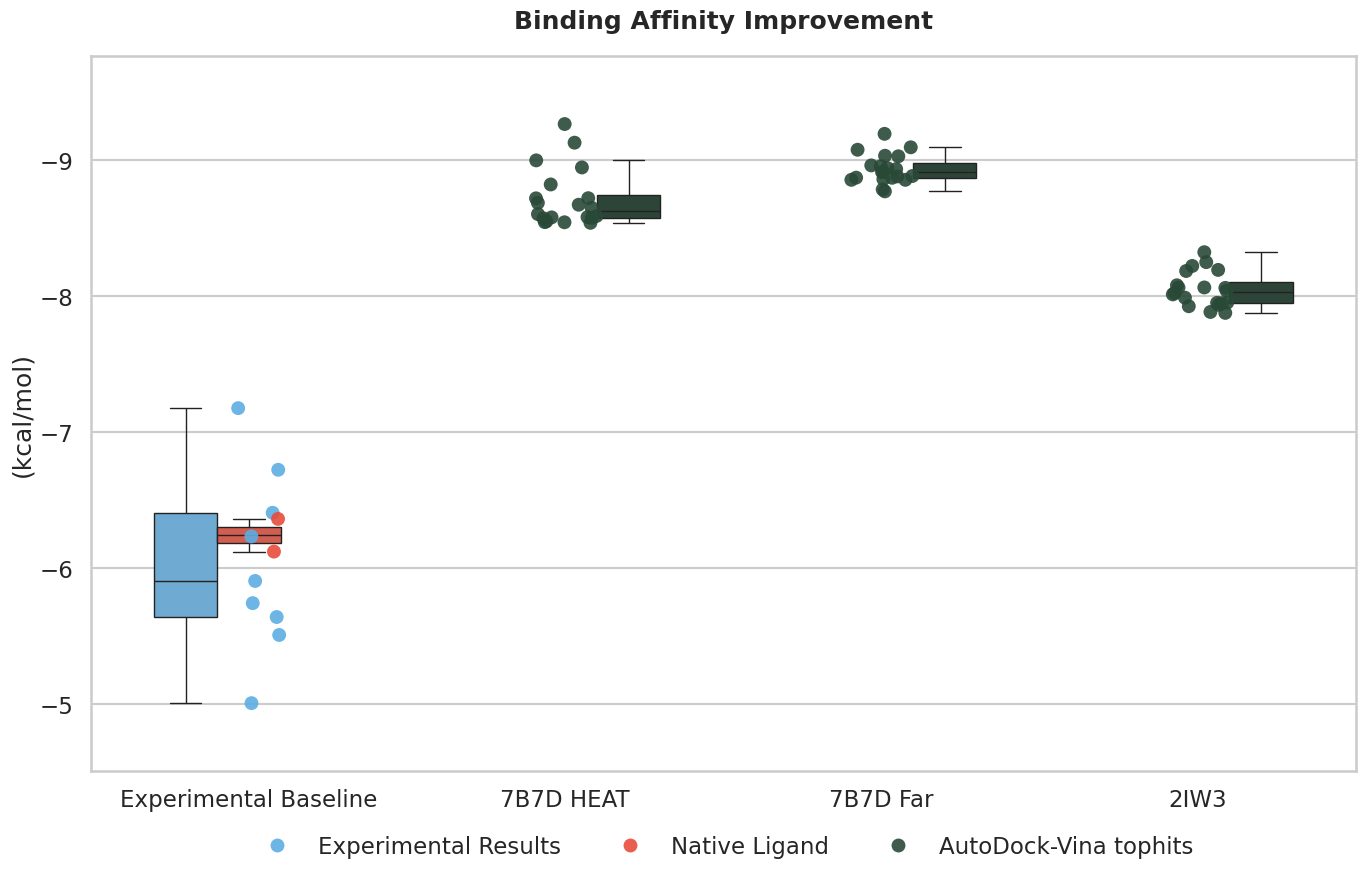

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the new master CSV
df = pd.read_csv('YeF3_allpockets_top50_results.csv')

# 2. Setup Plot Canvas (Widened to 14x8 to fit 4 distinct columns!)
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", context="talk")

# 3. Define the Color Palette
palette = {
    'Experimental Results': '#5DADE2',        
    'Native Ligand': '#e74c3c', 
    'AutoDock-Vina tophits': "#294937"          
}

# 4. Draw the plot
pockets = list(df['Pocket'].dropna().unique())
positions = np.arange(len(pockets)) * 0.8

ax = sns.boxplot(
    data=df,
    x='Pocket',       
    y='score',        # Note: lowercase 'score'
    hue='Category',   
    palette=palette,
    fliersize=0,      
    width=0.6,
    legend=False,
    order=pockets,
    hue_order=list(palette.keys()),
    positions=positions
)

ax = sns.stripplot(
    data=df,
    x='Pocket',       
    y='score',        # Note: lowercase 'score'
    hue='Category',   
    palette=palette,
    size=10,
    alpha=0.9,      
    legend=True,
    order=pockets,
    hue_order=list(palette.keys()),
    positions=positions
)

# 5. Invert Y-axis
bottom_limit = df['score'].max() + 0.5
top_limit = df['score'].min() - 0.5
ax.set_ylim(bottom_limit, top_limit)

# 7. Final Formatting
ax.set_xlabel('')
ax.set_ylabel('(kcal/mol)')
ax.set_title('Binding Affinity Improvement', pad=20, weight='bold')

# Put the labels at the tighter positions and keep padding on the edges
ax.set_xticks(positions)
ax.set_xticklabels(pockets)
ax.set_xlim(positions[0] - 0.45, positions[-1] + 0.45)

sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, title=None, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("YeF3_AllPockets_swarmplot.png", format="png", bbox_inches="tight", dpi=300)
plt.show()